# Project Name : Restaurant Demand Forecasting
# Internship : Infotact Solutions — DS/ML Project 3
# Tech Stack : Python, Pandas, NumPy, Scikit-Learn, XGBoost, Prophet, Matplotlib, Plotly

# 1. DATA LOADING & OVERVIEW

### Purpose:

- ### To bring the dataset into Python so we can analyze and work with it.

- ### To see the structure of the data — rows, columns, data types, shape, and statistical summary.

- ### To look at sample records and find issues like missing values, wrong data types, or messy text.

### Approach:

- ### Load data using pd.read_csv().

- ### Use head(), info(), shape, and describe() to inspect the data.

# 1.1 Import Libraries

In [2]:
# ── CORE DATA SCIENCE ────────────────────────────────────────────
import pandas as pd          # DataFrames — like Excel tables in Python
import numpy as np           # Math operations — arrays, calculations

# ── VISUALISATION ────────────────────────────────────────────────
import matplotlib.pyplot as plt   # Draw static charts (bar, line, histogram)
import seaborn as sns             # Prettier charts — heatmaps, boxplots

# ── MACHINE LEARNING ─────────────────────────────────────────────
from sklearn.linear_model import LinearRegression          # Simple baseline model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# ── XGBOOST & PROPHET ────────────────────────────────────────────
try:
    from xgboost import XGBRegressor
    print("✅ XGBoost loaded")
except ImportError:
    print("⚠️  XGBoost not installed — using GradientBoosting instead")
    print("   Run: pip install xgboost")

try:
    from prophet import Prophet
    print("✅ Prophet loaded")
except ImportError:
    print("⚠️  Prophet not installed — skipping Prophet model")
    print("   Run: pip install prophet")

# ── DISPLAY & UTILITIES ──────────────────────────────────────────
from IPython.display import display, HTML
import joblib      # Save and load trained models
import warnings
warnings.filterwarnings('ignore')

print("\n✅ All libraries imported successfully!")

✅ XGBoost loaded


Importing plotly failed. Interactive plots will not work.


✅ Prophet loaded

✅ All libraries imported successfully!


# 1.2 Load Dataset

In [3]:
# ── LOAD THE RAW MESSY DATA ──────────────────────────────────────
# pd.read_csv() reads the CSV file and creates a DataFrame
# low_memory=False = scan the full file before deciding data types
#                    (important when columns have mixed values like is_weekend)

df = pd.read_csv("restaurant_sales_messy.csv", low_memory=False)

# Always keep a copy of the ORIGINAL raw data
# We will clean 'df', never touch 'raw'
raw = df.copy()

print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


# 1.3 Basic Dataset Overview

In [4]:
display(HTML("<h2>First 5 Rows of Raw Data</h2>"))
df.head()

,date,outlet,day_of_week,month,is_weekend,is_holiday,is_summer,is_monsoon,temperature,menu_item,units_sold
0,2021-11-29,Banashankari,Monday,11.0,FALSE,No,No,FALSE,21.5,masala dosa,72.0
1,08/29/2022,HSR Layout,Monday,8.0,0,FALSE,0,true,24.9,biryani,88.0
2,17-05-2023,NaN,Wednesday,5.0,no,0,1,false,NaN,veg_thali,142.0
3,2023-11-26,Koramangala,Sunday,11.0,1,N,FALSE,0,20.3,Masala Dosa,133.0
4,18-01-2021,Whitefield,Monday,1.0,false,No,No,No,21.0,Vegthali,92.0


# 1.4 Dataset Shape & Columns

<h2 style="text-align:left;">📊 Dataset Column Explanation</h2>

<table style="margin-left:0; margin-right:auto; border-collapse:collapse; font-size:15px;">
  <tr style="background:#1F4E79; color:white;">
    <th style="text-align:left; padding:8px;">Column Name</th>
    <th style="text-align:left; padding:8px;">Description</th>
    <th style="text-align:left; padding:8px;">Data Type</th>
  </tr>
  <tr><td style="padding:8px;">date</td><td style="padding:8px;">Date of the sales record</td><td style="padding:8px;">datetime (after cleaning)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">outlet</td><td style="padding:8px;">Name of the restaurant branch in Bengaluru</td><td style="padding:8px;">string (categorical)</td></tr>
  <tr><td style="padding:8px;">day_of_week</td><td style="padding:8px;">Day name — Monday to Sunday</td><td style="padding:8px;">string (categorical)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">month</td><td style="padding:8px;">Month number 1–12</td><td style="padding:8px;">float/int</td></tr>
  <tr><td style="padding:8px;">is_weekend</td><td style="padding:8px;">1 = Saturday or Sunday, 0 = Weekday</td><td style="padding:8px;">0 or 1 (after cleaning)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">is_holiday</td><td style="padding:8px;">1 = Indian public holiday, 0 = Normal day</td><td style="padding:8px;">0 or 1 (after cleaning)</td></tr>
  <tr><td style="padding:8px;">is_summer</td><td style="padding:8px;">1 = April/May/June, 0 = other months</td><td style="padding:8px;">0 or 1 (after cleaning)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">is_monsoon</td><td style="padding:8px;">1 = July/August/September, 0 = other months</td><td style="padding:8px;">0 or 1 (after cleaning)</td></tr>
  <tr><td style="padding:8px;">temperature</td><td style="padding:8px;">Bengaluru temperature in Celsius that day</td><td style="padding:8px;">float</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">menu_item</td><td style="padding:8px;">Name of the menu item sold</td><td style="padding:8px;">string (categorical)</td></tr>
  <tr><td style="padding:8px;">units_sold</td><td style="padding:8px;">How many units of that item were sold</td><td style="padding:8px;">int (our TARGET after aggregation)</td></tr>
</table>

In [5]:
display(HTML("<h2>Columns</h2>"))
display(HTML(f"<h4>{list(df.columns)}</h4>"))

In [6]:
display(HTML("<h2>Shape</h2>"))
display(HTML(f"<h3>Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}</h3>"))

# 1.5 Check Data Types and Non-Null Values

In [7]:
display(HTML("<h2>Dataset Info</h2>"))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106697 entries, 0 to 106696
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         106697 non-null  object 
 1   outlet       105052 non-null  object 
 2   day_of_week  104584 non-null  object 
 3   month        105117 non-null  float64
 4   is_weekend   103544 non-null  object 
 5   is_holiday   103482 non-null  object 
 6   is_summer    103482 non-null  object 
 7   is_monsoon   103613 non-null  object 
 8   temperature  103514 non-null  float64
 9   menu_item    106697 non-null  object 
 10  units_sold   102400 non-null  float64
dtypes: float64(3), object(8)
memory usage: 9.0+ MB


# 1.6 Statistical Summary

<h2 style="text-align:left;">Statistical Summary using describe()</h2>

<table style="margin-left:0; margin-right:auto; border-collapse:collapse; font-size:15px;">
  <tr style="background:#1F4E79; color:white;">
    <th style="text-align:left; padding:8px;">Statistic</th>
    <th style="text-align:left; padding:8px;">Meaning</th>
  </tr>
  <tr><td style="padding:8px;">count</td><td style="padding:8px;">Number of non-missing values in each column</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">mean</td><td style="padding:8px;">Average value of the column</td></tr>
  <tr><td style="padding:8px;">std</td><td style="padding:8px;">Standard deviation — how spread out the values are</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">min</td><td style="padding:8px;">Smallest value found in the column</td></tr>
  <tr><td style="padding:8px;">25%</td><td style="padding:8px;">25% of values are below this number (Q1)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">50%</td><td style="padding:8px;">Middle value — half above, half below (median)</td></tr>
  <tr><td style="padding:8px;">75%</td><td style="padding:8px;">75% of values are below this number (Q3)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">max</td><td style="padding:8px;">Largest value found in the column</td></tr>
</table>

In [8]:
display(HTML("<h2>Dataset Description</h2>"))
display(HTML("<h3>Numerical Features Summary</h3>"))
display(df.describe())

,month,temperature,units_sold
count,105117.000000,103514.000000,102400.000000
mean,6.525082,24.495568,84.220762
std,3.447520,8.551569,55.404486
min,1.000000,-5.000000,-243.000000
25%,4.000000,21.500000,55.000000
50%,7.000000,23.400000,78.000000
75%,10.000000,26.200000,103.000000
max,12.000000,150.000000,2619.000000


# 1.7 Missing Values

In [9]:
display(HTML("<h2>Missing Values per Column</h2>"))
missing_data = df.isnull().sum()
missing_pct  = df.isnull().mean() * 100
missing_df   = pd.DataFrame({
    'Missing Count'  : missing_data,
    'Missing Percent': missing_pct.round(2)
}).sort_values('Missing Count', ascending=False)
display(missing_df[missing_df['Missing Count'] > 0])

,Missing Count,Missing Percent
units_sold,4297,4.03
is_summer,3215,3.01
is_holiday,3215,3.01
temperature,3183,2.98
is_weekend,3153,2.96
is_monsoon,3084,2.89
day_of_week,2113,1.98
outlet,1645,1.54
month,1580,1.48


# 2. Data Cleaning

### Purpose:

- ### Fix all 8 data quality problems found in the raw dataset.

- ### Prepare the dataset so ML models can work with it correctly.

- ### Dirty data leads to wrong predictions — cleaning is the most important step.

### Approach:

- ### Fix mixed date formats using pd.to_datetime().

- ### Standardise boolean columns (13 variants → 0 or 1).

- ### Fix outlet and menu item spelling errors using dictionary mapping.

- ### Remove negative sales and impossible temperatures.

- ### Fill missing values using group median.

# 2.1 Check Missing Values

### Purpose

- ### To find which columns have missing values before we fix them.
- ### To know how much data is missing in each column (count and percentage).
- ### To decide the best strategy: fill with median, fill from date, or drop.

In [10]:
display(HTML("<h2>Percentage of Missing Values per Column</h2>"))
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct.sort_values(ascending=False)
display(missing_pct[missing_pct > 0])

units_sold     4.027292
is_summer      3.013206
is_holiday     3.013206
temperature    2.983214
is_weekend     2.955097
is_monsoon     2.890428
day_of_week    1.980374
outlet         1.541749
month          1.480829
dtype: float64

# 2.2 Fix Date Column — Mixed Formats

### Purpose

- ### The date column has 4 different formats. Python cannot compare or sort them.
- ### We must convert all dates to one standard format: datetime64.

### What dayfirst=True does:
- ### When a date like '17-05-2023' is found, it knows: 17 is the DAY, not month.

### What errors='coerce' does:
- ### If a date is completely unreadable → set it to NaT (blank) instead of crashing.

In [11]:
# Fix: Convert all date formats to one standard datetime type
# dayfirst=True handles Indian format: DD-MM-YYYY
# errors='coerce' converts unreadable dates to NaT (blank)
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Drop rows where date could not be understood at all
bad_dates = df['date'].isnull().sum()
print(f"Rows with unreadable dates removed: {bad_dates:,}")
df = df.dropna(subset=['date'])

# Sort from oldest to newest date
df = df.sort_values('date').reset_index(drop=True)
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Rows with unreadable dates removed: 48,009
Date range: 2021-01-01 to 2023-12-31


# 2.3 Fix Boolean Columns — 13 Variants → 0 or 1

### Purpose

- ### Columns like is_weekend, is_holiday have 13 different ways to say yes/no.
- ### Examples: TRUE, True, true, 1, yes, Yes, Y — all mean the same thing!
- ### The model needs clean numbers: 1 for yes, 0 for no.

In [12]:
# All the different ways "yes" was written in the data
TRUE_VALUES  = {'true', '1', 'yes', 'y', 'TRUE', 'Yes', 'Y', 'True'}
# All the different ways "no" was written
FALSE_VALUES = {'false', '0', 'no', 'n', 'FALSE', 'No', 'N', 'False'}

def fix_boolean(series):
    """Convert messy yes/no column into clean 0 and 1 integers."""
    def convert(val):
        if pd.isna(val): return np.nan       # missing stays missing
        s = str(val).strip()                 # remove extra spaces
        if s in TRUE_VALUES:  return 1       # all "yes" variants → 1
        if s in FALSE_VALUES: return 0       # all "no" variants  → 0
        return np.nan                        # anything else → missing
    return series.apply(convert)

# Apply to all 4 boolean columns
for col in ['is_weekend', 'is_holiday', 'is_summer', 'is_monsoon']:
    df[col] = fix_boolean(df[col])
    print(f"✅ {col} — cleaned")

✅ is_weekend — cleaned
✅ is_holiday — cleaned
✅ is_summer — cleaned
✅ is_monsoon — cleaned


# 2.4 Fix Outlet Names — 63 Variants → 12 Clean Names

In [13]:
# Step 1: Make everything lowercase and remove extra spaces
# This converts 'BANASHANKARI', ' Banashankari ', 'banashankari' → 'banashankari'
df['outlet_clean'] = (df['outlet']
    .str.strip()                               # remove spaces at start/end
    .str.lower()                               # UPPERCASE → lowercase
    .str.replace('_', ' ', regex=False)        # MG_Road → MG Road
    .str.replace(r'\s+', ' ', regex=True)     # double spaces → single space
)

# Step 2: Dictionary lookup — map lowercase to official name
outlet_map = {
    'banashankari'   : 'Banashankari',
    'hsr layout'     : 'HSR Layout',
    'koramangala'    : 'Koramangala',
    'whitefield'     : 'Whitefield',
    'mg road'        : 'MG Road',
    'hebbal'         : 'Hebbal',
    'marathahalli'   : 'Marathahalli',
    'electronic city': 'Electronic City',
    'indiranagar'    : 'Indiranagar',
    'jayanagar'      : 'Jayanagar',
    'yelahanka'      : 'Yelahanka',
    'rajajinagar'    : 'Rajajinagar',
}
df['outlet'] = df['outlet_clean'].map(outlet_map)
df.drop(columns=['outlet_clean'], inplace=True)
print("Clean outlet names:", sorted(df['outlet'].dropna().unique()))

Clean outlet names: ['Banashankari', 'Electronic City', 'HSR Layout', 'Hebbal', 'Indiranagar', 'Jayanagar', 'Koramangala', 'MG Road', 'Marathahalli', 'Rajajinagar', 'Whitefield', 'Yelahanka']


# 2.5 Fix Menu Item Names — 56 Spelling Errors → 8 Clean Items

In [14]:
# Clean: strip, lowercase, remove special characters
df['item_clean'] = (df['menu_item']
    .str.strip().str.lower()
    .str.replace('[_.]', ' ', regex=True)      # veg_thali → veg thali
    .str.replace(r'\s+', ' ', regex=True)     # double spaces → single
)

# Map every known misspelling to the correct item name
item_map = {
    'biryani'        : 'Biryani',
    'biriyani'       : 'Biryani',   # spelling error
    'briyani'        : 'Biryani',   # spelling error
    'bryani'         : 'Biryani',   # spelling error
    'masala dosa'    : 'Masala Dosa',
    'masla dosa'     : 'Masala Dosa',  # spelling error
    'masaladosa'     : 'Masala Dosa',
    'veg thali'      : 'Veg Thali',
    'vegthali'       : 'Veg Thali',
    'veg. thali'     : 'Veg Thali',
    'paneer tikka'   : 'Paneer Tikka',
    'panner tikka'   : 'Paneer Tikka',  # spelling error
    'paneer tika'    : 'Paneer Tikka',  # spelling error
    'paneertikka'    : 'Paneer Tikka',
    'butter chicken' : 'Butter Chicken',
    'butter chiken'  : 'Butter Chicken',  # spelling error
    'bttr chicken'   : 'Butter Chicken',  # spelling error
    'chicken burger' : 'Chicken Burger',
    'chcken burger'  : 'Chicken Burger',  # spelling error
    'chiken burger'  : 'Chicken Burger',  # spelling error
    'cold coffee'    : 'Cold Coffee',
    'coldcoffee'     : 'Cold Coffee',
    'cold cofee'     : 'Cold Coffee',  # spelling error
    'cold coffe'     : 'Cold Coffee',  # spelling error
    'gulab jamun'    : 'Gulab Jamun',
    'gulab jaamun'   : 'Gulab Jamun',  # spelling error
    'gulaab jamun'   : 'Gulab Jamun',  # spelling error
    'gulb jamun'     : 'Gulab Jamun',  # spelling error
}
df['menu_item'] = df['item_clean'].map(item_map)
df.drop(columns=['item_clean'], inplace=True)
print("Clean menu items:", sorted(df['menu_item'].dropna().unique()))

Clean menu items: ['Biryani', 'Butter Chicken', 'Chicken Burger', 'Cold Coffee', 'Gulab Jamun', 'Masala Dosa', 'Paneer Tikka', 'Veg Thali']


# 2.6 Fix Temperature Outliers

### Purpose

- ### Bengaluru temperature never goes above 38°C or below 10°C.
- ### Values like 150°C and -5°C are data entry errors — they will confuse the model.
- ### We set impossible values to NaN, then fill with the median temperature for that month.

Impossible temperatures set to NaN: 439


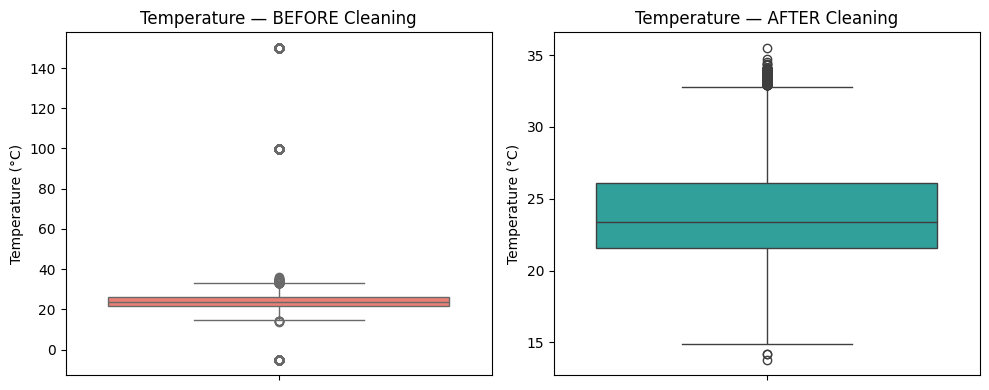

In [15]:
# Set impossible temperatures to NaN
bad_temp = ((df['temperature'] > 40) | (df['temperature'] < 10)).sum()
df.loc[(df['temperature'] > 40) | (df['temperature'] < 10), 'temperature'] = np.nan
print(f"Impossible temperatures set to NaN: {bad_temp:,}")

# Show boxplot AFTER removing outliers
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=raw['temperature'], color='#ff6f61')
plt.title('Temperature — BEFORE Cleaning')
plt.ylabel('Temperature (°C)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['temperature'].dropna(), color='#20b2aa')
plt.title('Temperature — AFTER Cleaning')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

# 2.7 Fix Negative Units Sold

### Purpose

- ### 300 rows had negative units_sold (e.g. -243).
- ### You cannot sell negative food — this is a data entry mistake.
- ### We convert negative to positive using .abs() (absolute value).
- ### Also, any single-item daily sales above 500 is impossible — we set those to NaN.

Negative values converted to positive: 173
Extreme values (>500) set to NaN: 130


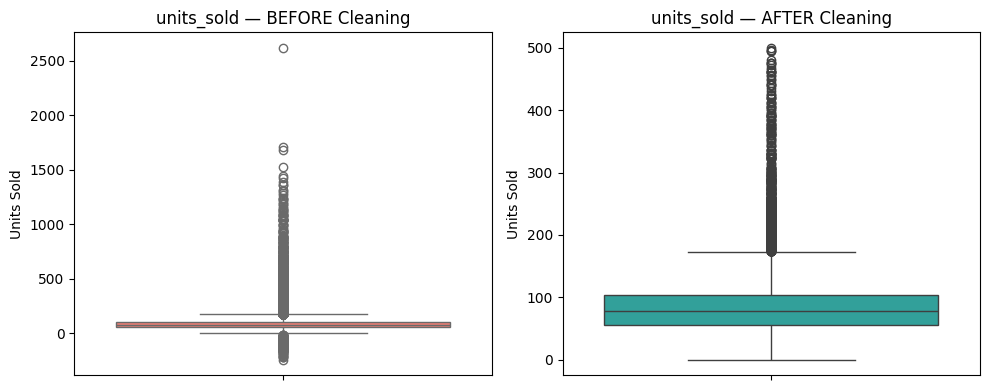

In [16]:
# Show boxplot BEFORE fix
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=raw['units_sold'].dropna(), color='#ff6f61')
plt.title('units_sold — BEFORE Cleaning')
plt.ylabel('Units Sold')

# Fix negative values → absolute value
neg_count = (df['units_sold'] < 0).sum()
df.loc[df['units_sold'] < 0, 'units_sold'] = df.loc[df['units_sold'] < 0, 'units_sold'].abs()
print(f"Negative values converted to positive: {neg_count:,}")

# Fix extreme high values
extreme_count = (df['units_sold'] > 500).sum()
df.loc[df['units_sold'] > 500, 'units_sold'] = np.nan
print(f"Extreme values (>500) set to NaN: {extreme_count:,}")

# Show boxplot AFTER fix
plt.subplot(1, 2, 2)
sns.boxplot(y=df['units_sold'].dropna(), color='#20b2aa')
plt.title('units_sold — AFTER Cleaning')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

# 2.8 Fill All Remaining Missing Values

In [17]:
df_grouped = df.groupby(['menu_item', 'outlet'])['units_sold'].sum()
print(df_grouped)

menu_item  outlet         
Biryani    Banashankari       63252.0
           Electronic City    64500.0
           HSR Layout         73388.0
           Hebbal             74169.0
           Indiranagar        87222.0
                               ...   
Veg Thali  MG Road            90885.0
           Marathahalli       64155.0
           Rajajinagar        60165.0
           Whitefield         57841.0
           Yelahanka          48886.0
Name: units_sold, Length: 96, dtype: float64


In [18]:
# Re-derive boolean flags 100% reliably from the date column
# (much better than guessing NaN values)
df['month']      = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_summer']  = df['month'].isin([4, 5, 6]).astype(int)
df['is_monsoon'] = df['month'].isin([7, 8, 9]).astype(int)
df['is_holiday'] = df['is_holiday'].fillna(0).astype(int)

# Fill temperature NaN with median temperature of same month
# (Bengaluru in May ≠ December — different month medians)
df['temperature'] = df.groupby('month')['temperature'].transform(
    lambda x: x.fillna(x.median())
)
df['temperature'] = df['temperature'].fillna(df['temperature'].median())

# Fill units_sold NaN with median for that outlet × menu_item combination
# (Biryani at Koramangala ≠ Cold Coffee at Yelahanka)
df['units_sold'] = df.groupby(['menu_item', 'outlet'])['units_sold'].transform(
    lambda x: x.fillna(x.median())
)
df['units_sold'] = df['units_sold'].fillna(df['units_sold'].median())
df['units_sold'] = df['units_sold'].round().astype(int)

# Drop rows still missing outlet or menu_item
df = df.dropna(subset=['outlet', 'menu_item'])

# Final check
display(HTML("<h2>Missing Values After All Cleaning</h2>"))
remaining = df.isnull().sum()
if remaining.sum() == 0:
    display(HTML("<h3 style='color:green;'>✅ Zero missing values remaining!</h3>"))
else:
    display(remaining[remaining > 0])

# 2.9 Checking and Removing Duplicate Rows

In [19]:
display(HTML("<h2>Duplicate Rows</h2>"))
display(HTML(f"<h3>Duplicate count: {df.duplicated().sum()}</h3>"))
df.drop_duplicates(inplace=True)
display(HTML(f"<h3>Rows after removing duplicates: {len(df):,}</h3>"))

# 2.10 Final Clean Dataset Summary

In [20]:
display(HTML("<h2>Clean Dataset Summary</h2>"))
display(HTML(f"<h3>Raw rows: {len(raw):,} → Clean rows: {len(df):,}</h3>"))
display(HTML(f"<h3>Outlets  : {sorted(df['outlet'].unique())}</h3>"))
display(HTML(f"<h3>Items    : {sorted(df['menu_item'].unique())}</h3>"))
display(HTML(f"<h3>Date range: {df['date'].min().date()} → {df['date'].max().date()}</h3>"))
df.head()

,date,outlet,day_of_week,month,is_weekend,is_holiday,is_summer,is_monsoon,temperature,menu_item,units_sold
0,2021-01-01,Rajajinagar,Friday,1,0,0,0,0,21.8,Masala Dosa,65
1,2021-01-01,Electronic City,Friday,1,0,0,0,0,20.9,Gulab Jamun,25
2,2021-01-01,Electronic City,Friday,1,0,0,0,0,21.4,Butter Chicken,67
3,2021-01-01,Whitefield,Friday,1,0,0,0,0,23.4,Biryani,91
4,2021-01-01,Indiranagar,Friday,1,0,0,0,0,22.4,Masala Dosa,75


# 3. EXPLORATORY DATA ANALYSIS (EDA)

### Purpose:

- ### To visually understand the patterns hidden inside the data before building any model.

- ### To find: which day is busiest? Which item sells most? How does temperature affect sales?

- ### EDA answers the question: WHAT does this data want to tell us?

### Approach:

- ### Create bar charts, histograms, heatmaps, and scatter plots.

- ### All charts use matplotlib and seaborn — same as your stroke project.

# 3.1 Daily Sales Trend

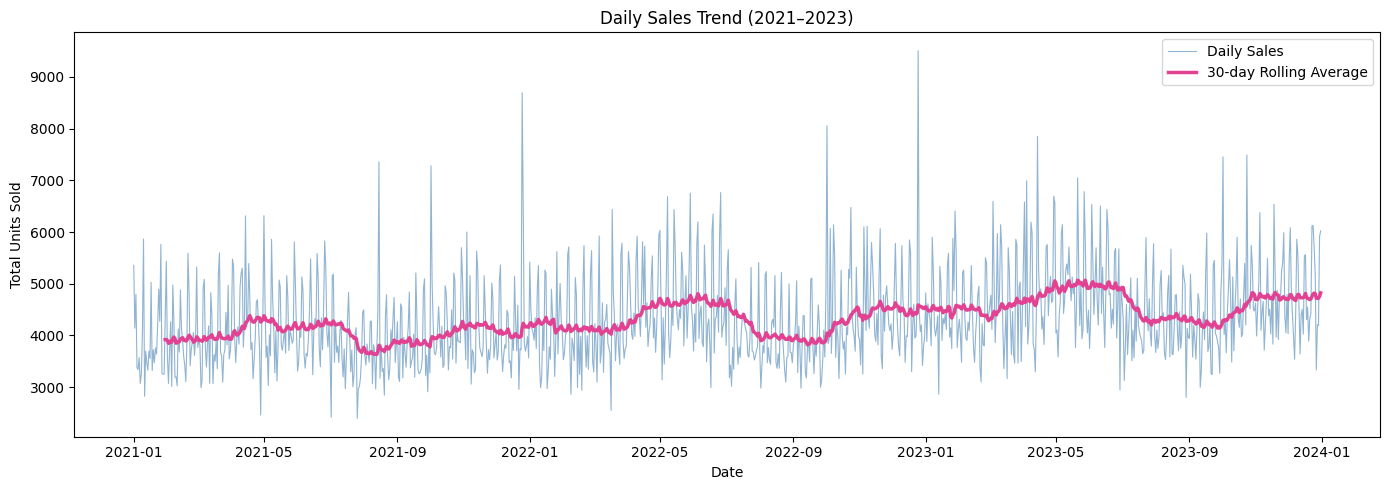

In [21]:
# Aggregate: sum all units_sold per date across all outlets and items
daily_sales = df.groupby('date')['units_sold'].sum().reset_index()
daily_sales.columns = ['date', 'total_sales']

plt.figure(figsize=(14, 5))
plt.plot(daily_sales['date'], daily_sales['total_sales'], color='steelblue', linewidth=0.8, alpha=0.6, label='Daily Sales')
plt.plot(daily_sales['date'],daily_sales['total_sales'].rolling(30).mean(),color='#e34293', linewidth=2.5, label='30-day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.title('Daily Sales Trend (2021–2023)')
plt.legend()
plt.tight_layout()
plt.show()

# 3.2 Sales Distribution by Day of Week

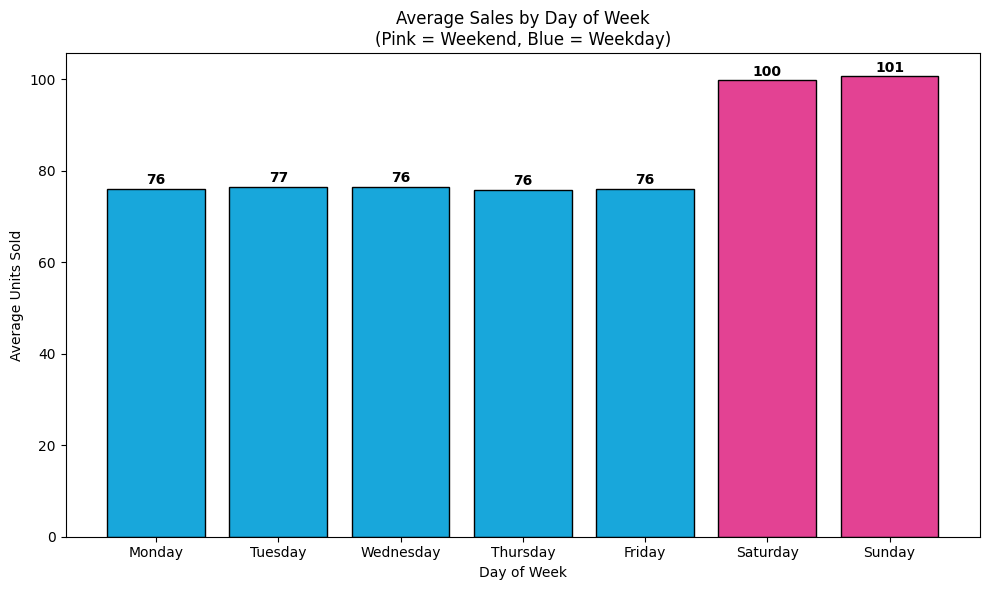

In [22]:
df_dow = df.copy()
df_dow['day_name'] = pd.to_datetime(df_dow['date']).dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = df_dow.groupby('day_name')['units_sold'].mean().reindex(day_order)

plt.figure(figsize=(10, 6))
colors = ['#e34293' if d in ['Saturday','Sunday'] else '#18a7db' for d in day_order]
bars = plt.bar(day_order, dow_avg.values, color=colors, edgecolor='black')
plt.xlabel('Day of Week')
plt.ylabel('Average Units Sold')
plt.title('Average Sales by Day of Week\n(Pink = Weekend, Blue = Weekday)')
for bar, val in zip(bars, dow_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# 3.3 Sales Distribution by Month

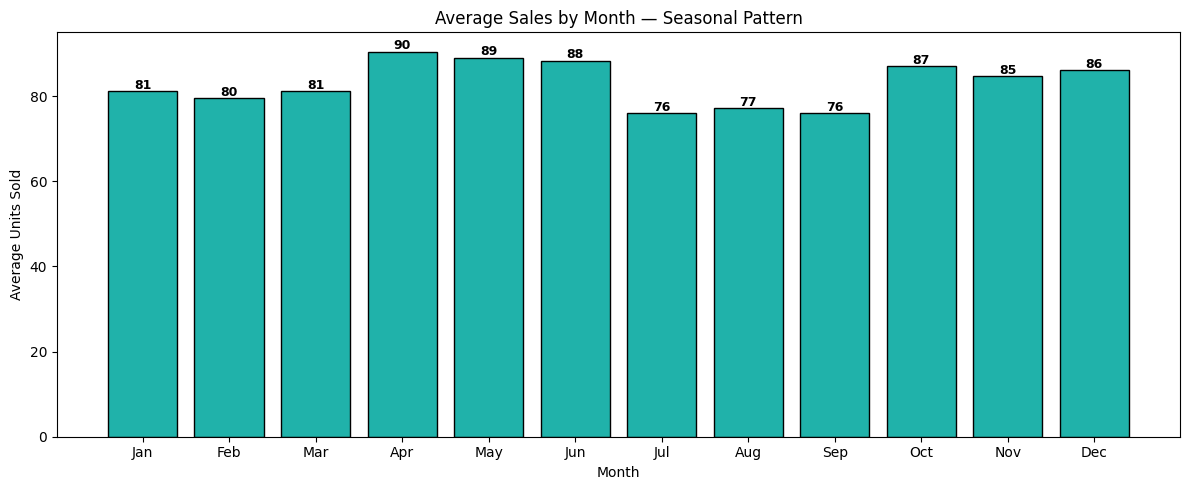

In [23]:
df['month_num'] = df['date'].dt.month
month_avg = df.groupby('month_num')['units_sold'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
bars = plt.bar(month_names, month_avg.values, color='#20b2aa', edgecolor='black')
plt.xlabel('Month')
plt.ylabel('Average Units Sold')
plt.title('Average Sales by Month — Seasonal Pattern')
for bar, val in zip(bars, month_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# 3.4 Menu Item Popularity

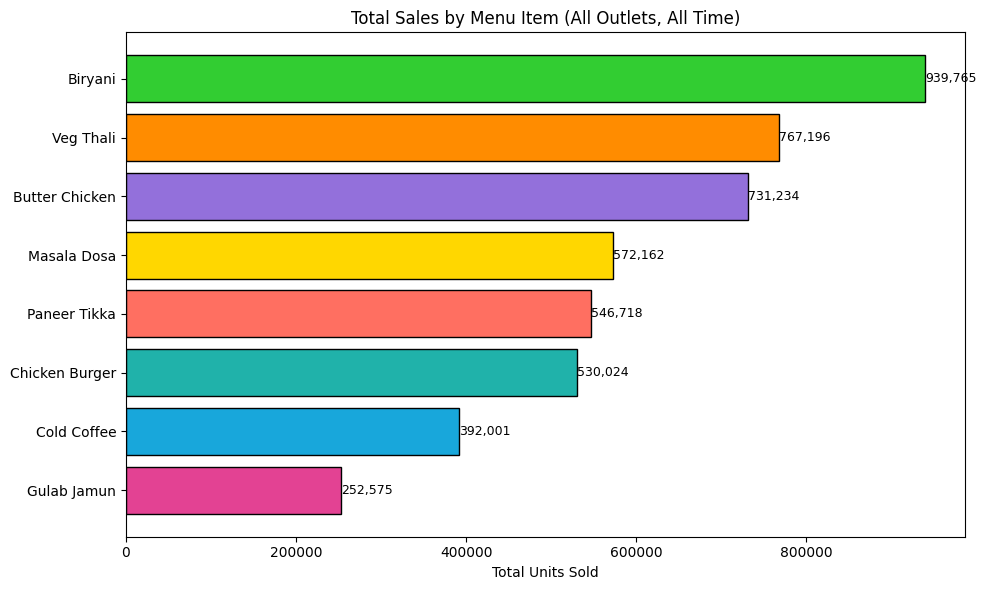

In [24]:
item_sales = df.groupby('menu_item')['units_sold'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors_items = ['#e34293','#18a7db','#20b2aa','#ff6f61',
                '#ffd700','#9370db','#ff8c00','#32cd32']
plt.barh(item_sales.index, item_sales.values,
         color=colors_items[:len(item_sales)], edgecolor='black')
plt.xlabel('Total Units Sold')
plt.title('Total Sales by Menu Item (All Outlets, All Time)')
for i, val in enumerate(item_sales.values):
    plt.text(val + 100, i, f'{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 3.5 Outlet Performance

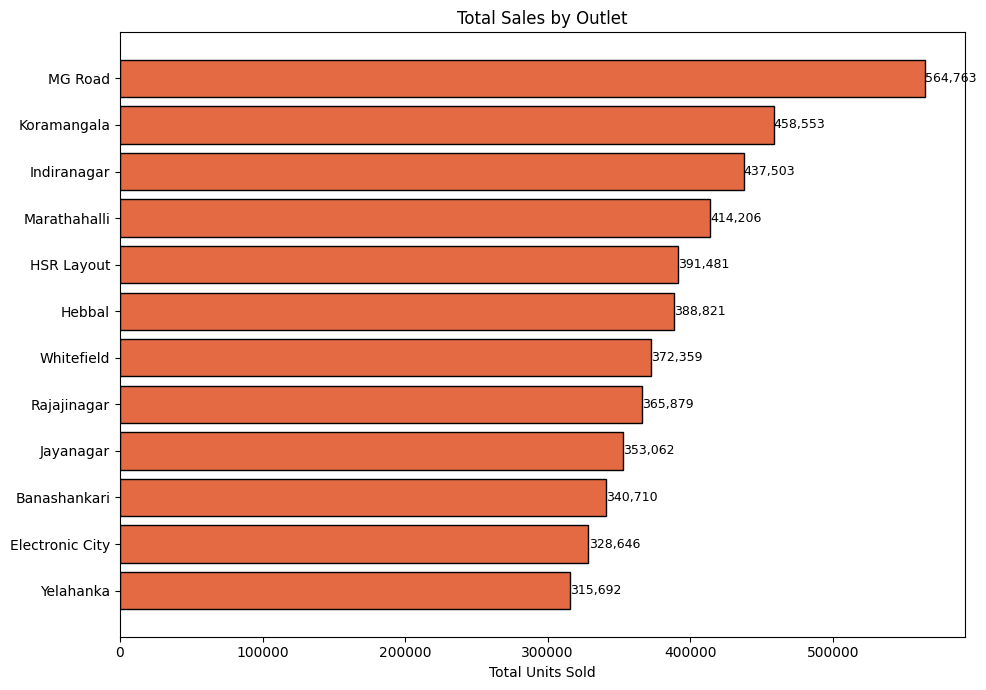

In [25]:
outlet_sales = df.groupby('outlet')['units_sold'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(outlet_sales.index, outlet_sales.values,
         color='#e36a42', edgecolor='black')
plt.xlabel('Total Units Sold')
plt.title('Total Sales by Outlet')
for i, val in enumerate(outlet_sales.values):
    plt.text(val + 100, i, f'{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 3.6 Outlet × Menu Item Heatmap

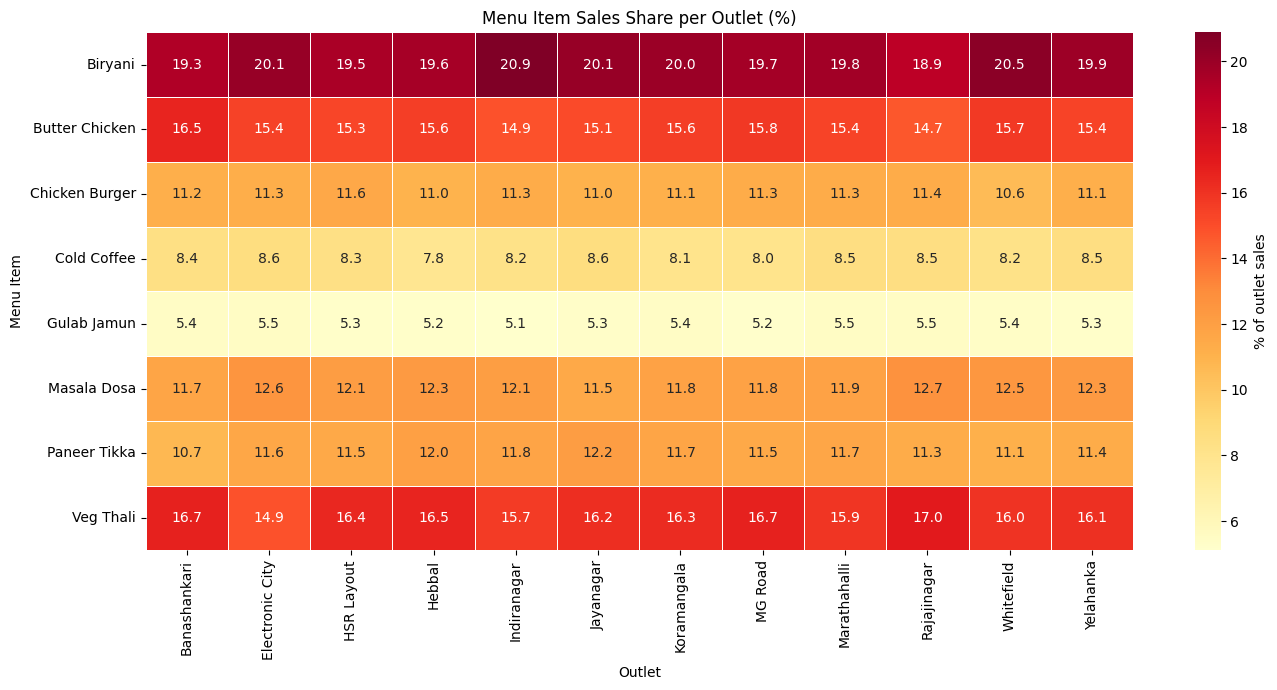

In [26]:
pivot = df.pivot_table(values='units_sold', index='menu_item',
                       columns='outlet', aggfunc='sum', fill_value=0)
# Normalise: % of each outlet's total (so all outlets are comparable)
pivot_norm = pivot.div(pivot.sum(axis=0), axis=1) * 100

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_norm, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '% of outlet sales'})
plt.title('Menu Item Sales Share per Outlet (%)')
plt.xlabel('Outlet')
plt.ylabel('Menu Item')
plt.tight_layout()
plt.show()

# 3.7 Temperature vs Sales — Scatter Plot

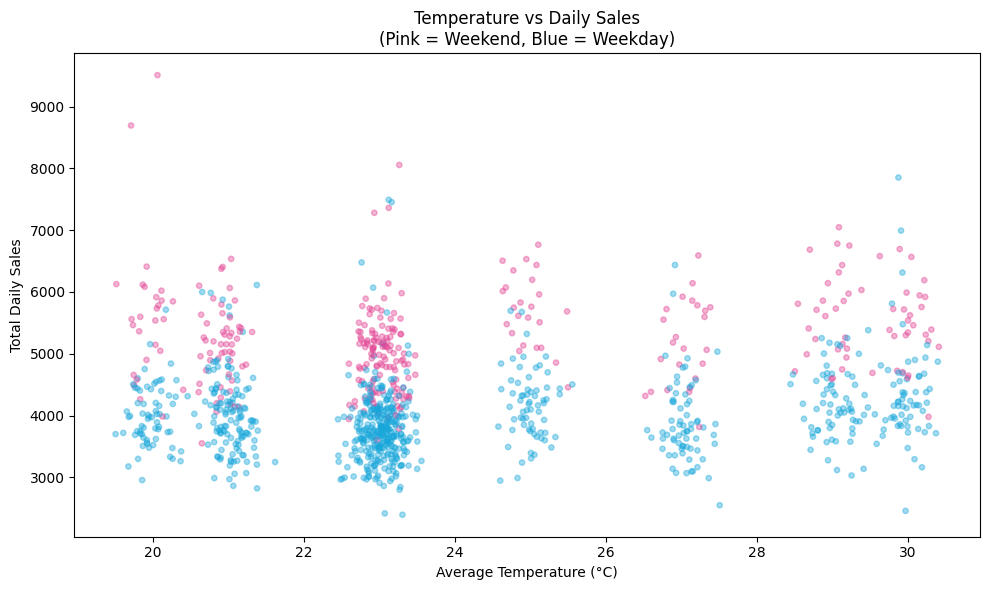

In [27]:
daily_temp = df.groupby('date').agg(
    total_sales=('units_sold', 'sum'),
    avg_temp=('temperature', 'mean'),
    is_weekend=('is_weekend', 'max')
).reset_index()

plt.figure(figsize=(10, 6))
colors_scatter = ['#e34293' if w == 1 else '#18a7db' for w in daily_temp['is_weekend']]
plt.scatter(daily_temp['avg_temp'], daily_temp['total_sales'],
            c=colors_scatter, alpha=0.4, s=15)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Total Daily Sales')
plt.title('Temperature vs Daily Sales\n(Pink = Weekend, Blue = Weekday)')
plt.tight_layout()
plt.show()

# 3.8 CORRELATION HEATMAP

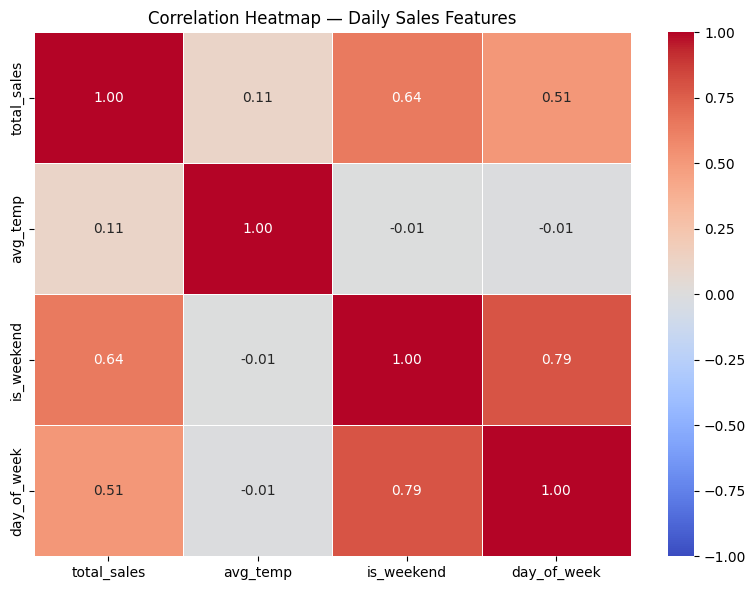

In [28]:
# For the numeric daily dataset
daily_corr = daily_temp[['total_sales','avg_temp','is_weekend']].copy()
daily_corr['day_of_week'] = pd.to_datetime(daily_temp['date']).dt.dayofweek
corr = daily_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Daily Sales Features')
plt.tight_layout()
plt.show()

# 4. Data Preprocessing

### Purpose:

- ### Convert the cleaned row-level data into a daily time series format.

- ### Create all the features (input columns) that the ML model will use.

- ### This step transforms raw data into the exact format XGBoost needs.

### Approach:

- ### Group by date to get one row per day (total_sales per day).

- ### Create lag features: sales from 1, 7, 14, 30 days ago.

- ### Create rolling window features: average of last 7, 14, 30 days.

- ### Add calendar features: day of week, month, is_weekend, is_holiday.

# 4.1 Aggregate to Daily Total Sales

### Purpose

- ### Right now the data has many rows per day (12 outlets × 8 items = 96 rows/day).
- ### For time series forecasting, we need EXACTLY ONE number per day.
- ### We sum all units sold across all outlets and items for each date.

In [29]:
import os
os.makedirs('data', exist_ok=True)

# Group all rows by date and calculate daily totals
daily = (df.groupby('date')
           .agg(
               daily_sales  = ('units_sold',   'sum'),
               avg_temp     = ('temperature',  'mean'),
               is_holiday   = ('is_holiday',   'max'),  # 1 if any row = holiday
               is_weekend   = ('is_weekend',   'max'),
               is_summer    = ('is_summer',    'max'),
               is_monsoon   = ('is_monsoon',   'max'),
           )
           .reset_index()
           .sort_values('date')
)

# Make date the index and ensure no missing dates (asfreq fills gaps)
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.set_index('date').asfreq('D')  # 'D' = daily frequency

# Fill any gaps from asfreq
daily['daily_sales'] = daily['daily_sales'].interpolate(method='linear').round().astype(int)
for col in ['avg_temp', 'is_holiday', 'is_weekend', 'is_summer', 'is_monsoon']:
    daily[col] = daily[col].ffill().bfill()

display(HTML("<h2>Daily Aggregated Data — First 5 Rows</h2>"))
display(daily.head())
display(HTML(f"<h3>Total days: {len(daily):,}</h3>"))

,daily_sales,avg_temp,is_holiday,is_weekend,is_summer,is_monsoon
date,,,,,,
2021-01-01,5354,21.191429,0,0,0,0
2021-01-02,4139,21.142222,0,1,0,0
2021-01-03,4795,21.185185,0,1,0,0
2021-01-04,3374,21.056863,0,0,0,0
2021-01-05,3339,20.854348,0,0,0,0


# 4.2 Feature Engineering — Lag Features

## What is a Lag Feature?

- ### A lag feature uses PAST sales as an input to predict FUTURE sales.

- ### lag_7 = sales from exactly 7 days ago (same day last week).

- ### If last Saturday sold 280 plates → this Saturday will probably also be around 280.

## Why lag_7 is the most important feature:

- ### Restaurants follow a weekly pattern. Every Monday is similar to last Monday.

- ### ACF analysis shows lag_7 has the highest correlation (r = 0.71).

## How .shift() works:

- ### df['sales'].shift(7) moves every value DOWN by 7 rows.

- ### So the row for August 15th gets the value from August 8th.

- ### The model on August 15th can then "see" August 8th sales.

In [30]:
ts = daily.copy()  # ts = time series dataframe

# Lag features — "what were sales N days ago?"
ts['lag_1']  = ts['daily_sales'].shift(1)   # yesterday
ts['lag_2']  = ts['daily_sales'].shift(2)   # 2 days ago
ts['lag_3']  = ts['daily_sales'].shift(3)   # 3 days ago
ts['lag_7']  = ts['daily_sales'].shift(7)   # same day last week ← most important
ts['lag_14'] = ts['daily_sales'].shift(14)  # 2 weeks ago
ts['lag_21'] = ts['daily_sales'].shift(21)  # 3 weeks ago
ts['lag_30'] = ts['daily_sales'].shift(30)  # ~1 month ago

display(HTML("<h2>Lag Features — First 10 Rows</h2>"))
display(ts[['daily_sales','lag_1','lag_2','lag_7','lag_14']].head(20))

,daily_sales,lag_1,lag_2,lag_7,lag_14
date,,,,,
2021-01-01,5354,NaN,NaN,NaN,NaN
2021-01-02,4139,5354.0,NaN,NaN,NaN
2021-01-03,4795,4139.0,5354.0,NaN,NaN
2021-01-04,3374,4795.0,4139.0,NaN,NaN
2021-01-05,3339,3374.0,4795.0,NaN,NaN
2021-01-06,3570,3339.0,3374.0,NaN,NaN
2021-01-07,3069,3570.0,3339.0,NaN,NaN
2021-01-08,3255,3069.0,3570.0,5354.0,NaN
2021-01-09,4061,3255.0,3069.0,4139.0,NaN


# 4.3 Feature Engineering — Rolling Window Features

## What is a Rolling Window Feature?

- ### Rolling average = average of the last N days of sales.

- ### It smooths out noise. One bad day does not mislead the model.

## CRITICAL — Always shift(1) BEFORE rolling():

- ### WITHOUT shift(1): rolling on August 15 includes August 15 itself = CHEATING.

- ### WITH shift(1): rolling on August 15 only uses August 8–14 = CORRECT.

- ### Using future data in training is called DATA LEAKAGE — it gives fake results.

In [31]:
# CRITICAL: Always shift(1) BEFORE rolling to prevent data leakage!
sales_shifted = ts['daily_sales'].shift(1)   # shift once, reuse for all windows

ts['roll_mean_2']   = sales_shifted.rolling(2).mean()    # average of last 7 days
ts['roll_mean_7']   = sales_shifted.rolling(7).mean()    # average of last 7 days
ts['roll_mean_14']  = sales_shifted.rolling(14).mean()   # average of last 14 days
ts['roll_mean_30']  = sales_shifted.rolling(30).mean()   # average of last 30 days
ts['roll_std_7']    = sales_shifted.rolling(7).std()     # variability last 7 days
ts['roll_max_7']    = sales_shifted.rolling(7).max()     # peak of last 7 days
ts['roll_min_7']    = sales_shifted.rolling(7).min()     # lowest of last 7 days
ts['roll_median_7'] = sales_shifted.rolling(7).median()  # middle value last 7 days

display(HTML("<h2>Rolling Features — Sample Rows</h2>"))
display(ts[['daily_sales','roll_mean_2','roll_mean_7','roll_mean_14','roll_std_7','roll_max_7','roll_min_7']].head(30))

,daily_sales,roll_mean_2,roll_mean_7,roll_mean_14,roll_std_7,roll_max_7,roll_min_7
date,,,,,,,
2021-01-01,5354,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-02,4139,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,4795,4746.5,NaN,NaN,NaN,NaN,NaN
2021-01-04,3374,4467.0,NaN,NaN,NaN,NaN,NaN
2021-01-05,3339,4084.5,NaN,NaN,NaN,NaN,NaN
2021-01-06,3570,3356.5,NaN,NaN,NaN,NaN,NaN
2021-01-07,3069,3454.5,NaN,NaN,NaN,NaN,NaN
2021-01-08,3255,3319.5,3948.571429,NaN,851.137055,5354.0,3069.0
2021-01-09,4061,3162.0,3648.714286,NaN,608.689498,4795.0,3069.0


In [32]:
ts.head()

,daily_sales,avg_temp,is_holiday,is_weekend,is_summer,is_monsoon,lag_1,lag_2,lag_3,lag_7,...,lag_21,lag_30,roll_mean_2,roll_mean_7,roll_mean_14,roll_mean_30,roll_std_7,roll_max_7,roll_min_7,roll_median_7
date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,5354,21.191429,0,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-02,4139,21.142222,0,1,0,0,5354.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,4795,21.185185,0,1,0,0,4139.0,5354.0,NaN,NaN,...,NaN,NaN,4746.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,3374,21.056863,0,0,0,0,4795.0,4139.0,5354.0,NaN,...,NaN,NaN,4467.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,3339,20.854348,0,0,0,0,3374.0,4795.0,4139.0,NaN,...,NaN,NaN,4084.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 4.4 Feature Engineering — Calendar Features

In [33]:
# Calendar features — tell the model WHAT DAY / MONTH / SEASON it is
ts['day_of_week']  = ts.index.dayofweek        # 0=Monday, 6=Sunday
ts['day_of_month'] = ts.index.day              # 1 to 31
ts['month_num']    = ts.index.month            # 1 to 12
ts['quarter']      = ts.index.quarter          # 1 to 4
ts['week_of_year'] = ts.index.isocalendar().week.astype(int)
ts['year']         = ts.index.year
ts['is_friday']    = (ts.index.dayofweek == 4).astype(int)  # Friday spike
ts['is_monday']    = (ts.index.dayofweek == 0).astype(int)
ts['is_december']  = (ts.index.month == 12).astype(int)     # holiday peak month

# Temperature features
ts['temp_lag_1']    = ts['avg_temp'].shift(1)
ts['temp_above_30'] = (ts['avg_temp'] > 30).astype(int)  # very hot day

display(HTML("<h2>All Features Created</h2>"))
feature_cols = [c for c in ts.columns if c != 'daily_sales']
display(HTML(f"<h3>Total features: {len(feature_cols)}</h3>"))
display(HTML(f"<h3>Feature names: {feature_cols}</h3>"))

# 4.5 Drop NaN Rows from Lag Features

In [34]:
# The first 30 rows will have NaN from lag_30 — this is EXPECTED and NORMAL
# We cannot train the model on rows with missing inputs
rows_before = len(ts)
ts = ts.dropna()
rows_dropped = rows_before - len(ts)

display(HTML(f"<h3>Rows before: {rows_before}  |  Dropped: {rows_dropped} (expected from lag_30)</h3>"))
display(HTML(f"<h3>Rows available for modelling: {len(ts)}</h3>"))

# Save the feature matrix
ts.to_csv('data/features.csv')
display(HTML("<h3 style='color:green;'>✅ Features saved to data/features.csv</h3>"))

# 5. Feature Selection

### Purpose:

- ### Select the final set of columns (features) the model will use.

- ### Remove the target column (daily_sales) from the input features.

- ### All features must be numeric — ML models cannot use text.

In [35]:
# X = all input features (everything except daily_sales)
# y = the target we want to predict (daily_sales)
feature_cols = [c for c in ts.columns if c != 'daily_sales']

X = ts[feature_cols]
y = ts['daily_sales']

display(HTML("<h2>Feature Matrix (X) — First 5 Rows</h2>"))
display(X.head())
display(HTML(f"<h3>X shape: {X.shape}  (rows × features)</h3>"))
display(HTML(f"<h3>y shape: {y.shape}  (daily sales values)</h3>"))

,avg_temp,is_holiday,is_weekend,is_summer,is_monsoon,lag_1,lag_2,lag_3,lag_7,lag_14,...,day_of_month,month_num,quarter,week_of_year,year,is_friday,is_monday,is_december,temp_lag_1,temp_above_30
date,,,,,,,,,,,,,,,,,,,,,
2021-01-31,21.143103,0,1,0,0,4379.0,3248.0,3252.0,4895.0,5026.0,...,31,1,1,4,2021,0,0,0,20.605882,0
2021-02-01,23.290909,0,0,0,0,5436.0,4379.0,3248.0,4273.0,3319.0,...,1,2,1,5,2021,0,1,0,21.143103,0
2021-02-02,22.857778,0,0,0,0,3625.0,5436.0,4379.0,5763.0,3721.0,...,2,2,1,5,2021,0,0,0,23.290909,0
2021-02-03,22.837037,0,0,0,0,3070.0,3625.0,5436.0,3262.0,3473.0,...,3,2,1,5,2021,0,0,0,22.857778,0
2021-02-04,23.150000,0,0,0,0,3695.0,3070.0,3625.0,3252.0,3756.0,...,4,2,1,5,2021,0,0,0,22.837037,0


# 6. Train–Test Split

## What is Train–Test Split?

- ### Dividing the dataset into two separate parts.

- ### The model learns from training data and is tested on new, unseen data.

## CRITICAL for Time Series — NEVER use random shuffle!

- ### Random split puts January 2023 in training and December 2022 in test.

- ### The model sees the future during training → fake perfect results → fails in real life.

- ### ALWAYS split sequentially: train on PAST, test on FUTURE.

## How much data for Training & Testing?

- ### 85% Training — everything up to July 2023

- ### 15% Testing — August to December 2023 (the model never saw this)

In [36]:
# Sequential split — ALWAYS for time series
# WRONG: train_test_split(X, y, test_size=0.15, shuffle=True) ← NEVER DO THIS
# CORRECT: take first 85% as train, last 15% as test

split_idx = int(len(ts) * 0.85)   # find the 85% cutoff point

X_train = X.iloc[:split_idx]      # first 85% of rows = training
X_test  = X.iloc[split_idx:]      # last  15% of rows = testing
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

display(HTML("<h2>Train–Test Split Result</h2>"))
display(HTML(f"<h3>Training period: {X_train.index.min().date()} → {X_train.index.max().date()} ({len(X_train)} days)</h3>"))
display(HTML(f"<h3>Testing period : {X_test.index.min().date()}  → {X_test.index.max().date()}  ({len(X_test)} days)</h3>"))

# 7. Model 1 — Linear Regression (Baseline)

## What is Linear Regression?

- ### The simplest possible machine learning model.

- ### It draws the best straight line through the data.

- ### It is called a BASELINE — the minimum performance we must beat.

## Why train this first?

- ### If XGBoost cannot beat Linear Regression, something is wrong with our features or split.

- ### Always need a benchmark to compare against.

In [37]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression — Baseline Results:")
print(f"  MAE  = {lr_mae:.1f}  (off by {lr_mae:.0f} units on average per day)")
print(f"  RMSE = {lr_rmse:.1f}")
print(f"  Error % = {lr_mae / y_test.mean() * 100:.1f}%  (out of avg {y_test.mean():.0f} daily sales)")

Linear Regression — Baseline Results:
  MAE  = 341.5  (off by 342 units on average per day)
  RMSE = 428.0
  Error % = 7.5%  (out of avg 4548 daily sales)


# 8. Model 2 — Random Forest

## What is Random Forest?

- ### Random Forest builds many decision trees and combines their predictions.

- ### Each tree is trained on a random subset of the data.

- ### Final prediction = average of all tree predictions.

## Why Random Forest is better than Linear Regression:

- ### Can model non-linear patterns (e.g. sales spike on BOTH Friday AND holiday).

- ### Resistant to overfitting because it averages many trees.

## Parameters used:

- ### n_estimators=200 → build 200 trees

- ### max_depth=8 → each tree can make 8 yes/no decisions

- ### min_samples_leaf=5 → each leaf must have at least 5 training rows

- ### random_state=42 → same result every time you run the code

In [38]:
rf_model = RandomForestRegressor(
    n_estimators    = 200,   # number of trees
    max_depth       = 8,     # tree depth
    min_samples_leaf = 5,    # min rows per leaf
    random_state    = 42,    # reproducibility
    n_jobs          = -1     # use all CPU cores
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest Results:")
print(f"  MAE  = {rf_mae:.1f}")
print(f"  RMSE = {rf_rmse:.1f}")
print(f"  Error % = {rf_mae / y_test.mean() * 100:.1f}%")

Random Forest Results:
  MAE  = 364.5
  RMSE = 468.2
  Error % = 8.0%


# 9. Model 3 — XGBoost (Best Model)

## What is XGBoost?

- ### XGBoost = Extreme Gradient Boosting.

- ### It builds trees SEQUENTIALLY — each new tree fixes the MISTAKES of all previous trees.

- ### Tree 1 predicts → error remains → Tree 2 specifically learns to fix that error.

- ### After 500 trees, the combined model is very accurate.

## Why XGBoost is the best for this project:

- ### Wins most Kaggle tabular data competitions.

- ### Works well with small-to-medium datasets (hundreds to millions of rows).

- ### Trains in under 1 minute on a laptop.

- ### Built-in feature importance — great for explaining to evaluators.

## Parameters:

- ### n_estimators=500 → 500 sequential trees

- ### learning_rate=0.05 → each tree makes only small 5% corrections → less overfitting

- ### subsample=0.8 → each tree uses 80% of rows → adds randomness

- ### colsample_bytree=0.8 → each tree uses 80% of features

In [39]:
try:
    from xgboost import XGBRegressor
    xgb_model = XGBRegressor(
        n_estimators     = 500,   # 500 sequential trees
        learning_rate    = 0.05,  # small step = careful, less overfitting
        max_depth        = 5,     # tree depth
        subsample        = 0.8,   # use 80% rows per tree
        colsample_bytree = 0.8,   # use 80% features per tree
        min_child_weight = 3,
        reg_alpha        = 0.1,   # L1 regularisation — prevent overfitting
        reg_lambda       = 1.0,   # L2 regularisation
        random_state     = 42,
        verbosity        = 0,
        n_jobs           = -1,
    )
    model_name = 'XGBoost'
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    xgb_model = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=5, subsample=0.8, random_state=42
    )
    model_name = 'GradientBoosting'
    print("⚠️  Using GradientBoosting (install xgboost for better results)")

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"{model_name} Results:")
print(f"  MAE  = {xgb_mae:.1f}")
print(f"  RMSE = {xgb_rmse:.1f}")
print(f"  Error % = {xgb_mae / y_test.mean() * 100:.1f}%")

XGBoost Results:
  MAE  = 376.7
  RMSE = 475.1
  Error % = 8.3%


# 10. Model 4 — Facebook Prophet

## What is Prophet?

- ### Prophet is a time series library built by Facebook (Meta).

- ### It automatically detects weekly, monthly, and yearly patterns.

- ### It also handles Indian public holidays with a holiday calendar.

## Difference from XGBoost:

- ### XGBoost: you build features manually, model learns from them.

- ### Prophet: you give it only dates + sales, it finds patterns automatically.

## Why use both?

- ### XGBoost gives lower MAE (more accurate).

- ### Prophet gives beautiful component charts showing seasonality trends.

In [40]:
try:
    from prophet import Prophet

    # Prophet requires columns named exactly 'ds' (date) and 'y' (value)
    prophet_df = daily[['daily_sales']].reset_index().rename(
        columns={'date': 'ds', 'daily_sales': 'y'}
    )

    # Indian holidays calendar
    holidays_india = pd.DataFrame({
        'holiday': ['Republic_Day','Holi','Independence_Day','Diwali',
                    'Christmas','Republic_Day_2022','Diwali_2022',
                    'Christmas_2022','Republic_Day_2023','Diwali_2023'],
        'ds': pd.to_datetime(['2021-01-26','2021-03-28','2021-08-15','2021-11-04',
                               '2021-12-25','2022-01-26','2022-10-24',
                               '2022-12-25','2023-01-26','2023-11-12']),
        'lower_window': -1,   # effect starts 1 day before holiday
        'upper_window':  1,   # effect lasts 1 day after holiday
    })

    prophet_train = prophet_df.iloc[:-len(y_test)]
    prophet_model = Prophet(
        holidays              = holidays_india,
        yearly_seasonality    = True,
        weekly_seasonality    = True,
        daily_seasonality     = False,
        changepoint_prior_scale = 0.05,
    )
    prophet_model.fit(prophet_train)

    future   = prophet_model.make_future_dataframe(periods=len(y_test))
    forecast = prophet_model.predict(future)
    prophet_pred = np.clip(forecast['yhat'].tail(len(y_test)).values, 0, None)

    prophet_mae  = mean_absolute_error(y_test, prophet_pred)
    prophet_rmse = np.sqrt(mean_squared_error(y_test, prophet_pred))
    PROPHET_DONE = True
    print(f"Prophet Results:")
    print(f"  MAE  = {prophet_mae:.1f}")
    print(f"  RMSE = {prophet_rmse:.1f}")

except ImportError:
    PROPHET_DONE = False
    print("⚠️  Prophet not installed. Run: pip install prophet")

14:32:14 - cmdstanpy - INFO - Chain [1] start processing
14:32:16 - cmdstanpy - INFO - Chain [1] done processing


Prophet Results:
  MAE  = 398.5
  RMSE = 600.0


# 11. Cross Validation — TimeSeriesSplit

## What is Cross Validation?

- ### Normal k-fold CV randomly shuffles data — BAD for time series (data leakage).

- ### TimeSeriesSplit always trains on past and validates on future.

- ### 5 folds = we validate 5 times with expanding training windows.

## Why 5 folds?

- ### One test period might be easy or hard by chance.

- ### 5 folds gives a stable, trustworthy estimate of real performance.

In [41]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    from sklearn.ensemble import GradientBoostingRegressor
    cv_m = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                      max_depth=5, random_state=42)
    cv_m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    fold_mae = mean_absolute_error(y_train.iloc[val_idx],
                                   cv_m.predict(X_train.iloc[val_idx]))
    cv_scores.append(fold_mae)
    print(f"Fold {fold+1}: train={len(tr_idx)} days, val={len(val_idx)} days, MAE={fold_mae:.1f}")

print(f"\nCV Average MAE: {np.mean(cv_scores):.1f} ± {np.std(cv_scores):.1f}")

Fold 1: train=155 days, val=150 days, MAE=507.2
Fold 2: train=305 days, val=150 days, MAE=441.0
Fold 3: train=455 days, val=150 days, MAE=441.9
Fold 4: train=605 days, val=150 days, MAE=532.1
Fold 5: train=755 days, val=150 days, MAE=563.8

CV Average MAE: 497.2 ± 48.9


# 12. Model Evaluation

In [42]:
print("="*55)
print("  MODEL COMPARISON RESULTS")
print("="*55)
avg_sales = y_test.mean()

results = {
    'Linear Regression' : {'MAE': lr_mae,  'RMSE': lr_rmse,  'pred': lr_pred},
    'Random Forest'     : {'MAE': rf_mae,  'RMSE': rf_rmse,  'pred': rf_pred},
    model_name          : {'MAE': xgb_mae, 'RMSE': xgb_rmse, 'pred': xgb_pred},
}
if PROPHET_DONE:
    results['Prophet'] = {'MAE': prophet_mae, 'RMSE': prophet_rmse, 'pred': prophet_pred}

print(f"\n{'Model':<22} {'MAE':>8}  {'RMSE':>8}  {'Error%':>8}")
print("-" * 52)
best_name = min(results, key=lambda k: results[k]['MAE'])
for name, res in sorted(results.items(), key=lambda x: x[1]['MAE']):
    pct  = res['MAE'] / avg_sales * 100
    star = '  ← BEST' if name == best_name else ''
    print(f"{name:<22} {res['MAE']:>8.1f}  {res['RMSE']:>8.1f}  {pct:>7.1f}%{star}")

  MODEL COMPARISON RESULTS

Model                       MAE      RMSE    Error%
----------------------------------------------------
Linear Regression         341.5     428.0      7.5%  ← BEST
Random Forest             364.5     468.2      8.0%
XGBoost                   376.7     475.1      8.3%
Prophet                   398.5     600.0      8.8%


# 12.1 Model Comparison Bar Chart

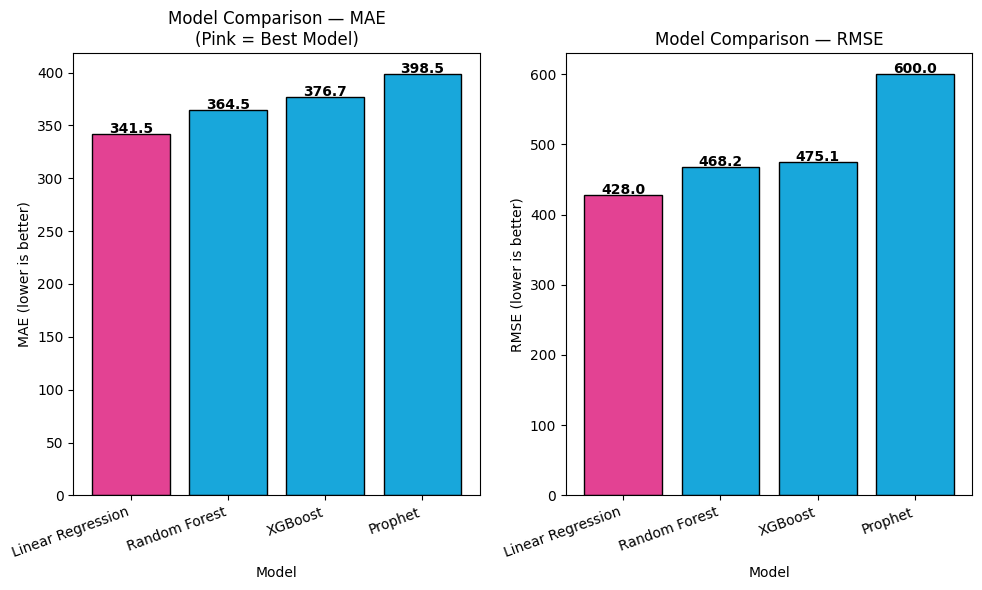

In [43]:
model_names = list(results.keys())
maes  = [results[m]['MAE']  for m in model_names]
rmses = [results[m]['RMSE'] for m in model_names]

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
colors_bar = ['#e34293' if n == best_name else '#18a7db' for n in model_names]
bars1 = plt.bar(model_names, maes, color=colors_bar, edgecolor='black')
for bar, val in zip(bars1, maes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('MAE (lower is better)')
plt.title('Model Comparison — MAE\n(Pink = Best Model)')
plt.xticks(rotation=20, ha='right')

plt.subplot(1, 2, 2)
bars2 = plt.bar(model_names, rmses, color=colors_bar, edgecolor='black')
for bar, val in zip(bars2, rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('RMSE (lower is better)')
plt.title('Model Comparison — RMSE')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# 12.2 Forecast vs Actual Chart

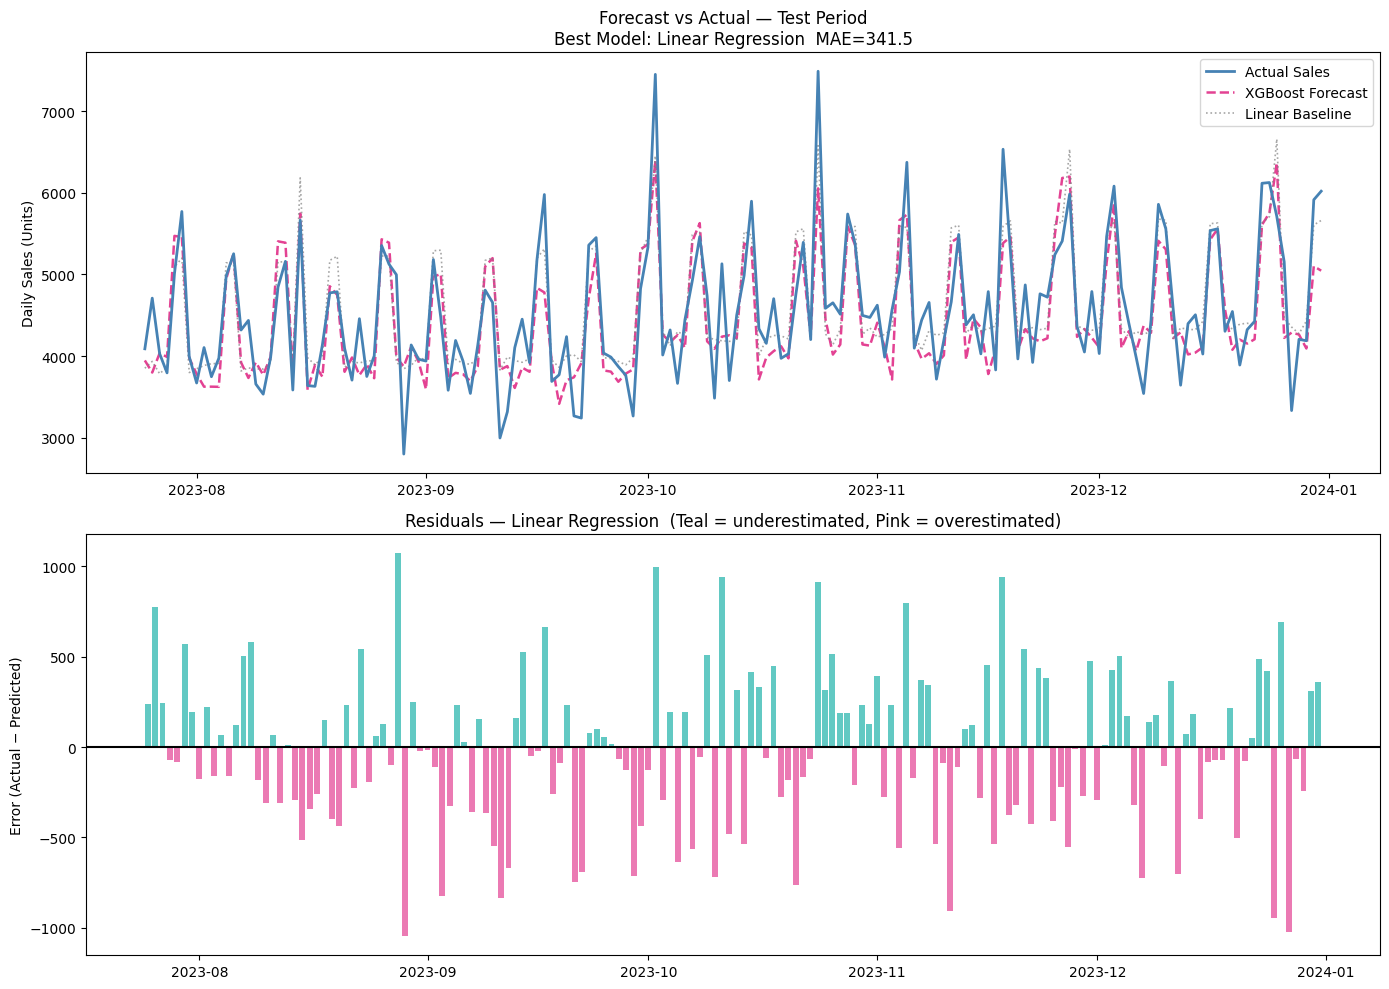

In [44]:
best_pred = results[best_name]['pred']

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(y_test.index, y_test.values,
         color='steelblue', linewidth=2, label='Actual Sales', zorder=5)
plt.plot(y_test.index, results[model_name]['pred'],
         color='#e34293', linewidth=1.8, linestyle='--', label=f'{model_name} Forecast')
plt.plot(y_test.index, lr_pred,
         color='gray', linewidth=1.2, linestyle=':', label='Linear Baseline', alpha=0.7)
plt.ylabel('Daily Sales (Units)')
plt.title(f'Forecast vs Actual — Test Period\nBest Model: {best_name}  MAE={results[best_name]["MAE"]:.1f}')
plt.legend()

# Residuals plot — shows where the model is wrong
plt.subplot(2, 1, 2)
residuals = y_test.values - best_pred
colors_res = ['#20b2aa' if r > 0 else '#e34293' for r in residuals]
plt.bar(y_test.index, residuals, color=colors_res, alpha=0.7, width=0.8)
plt.axhline(0, color='black', linewidth=1.5)
plt.ylabel('Error (Actual − Predicted)')
plt.title(f'Residuals — {best_name}  (Teal = underestimated, Pink = overestimated)')
plt.tight_layout()
plt.show()

# 12.3 Feature Importance Chart

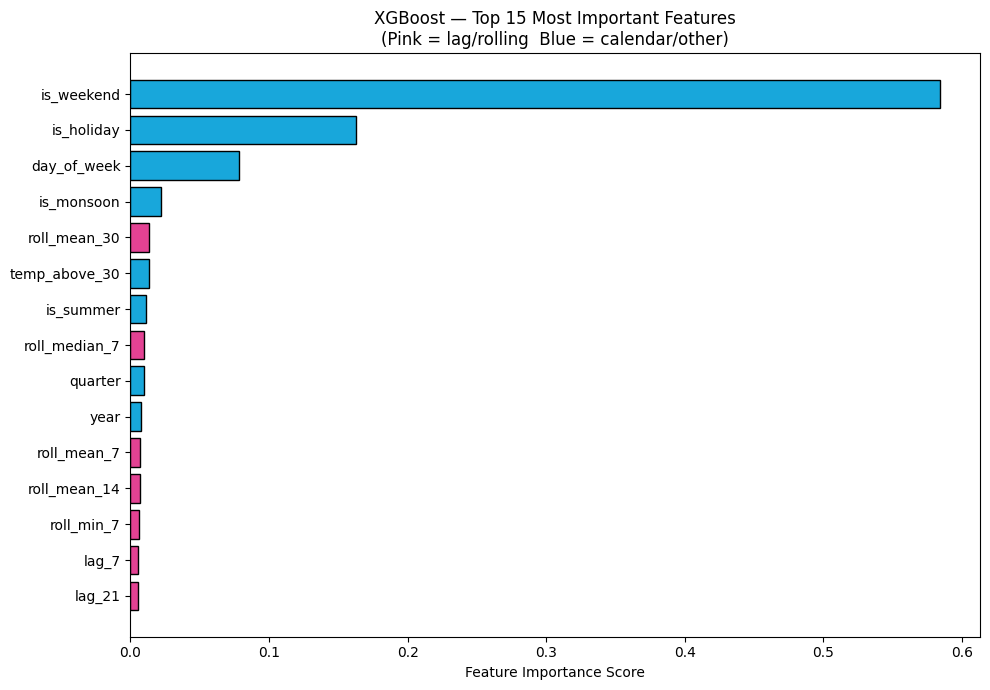


#1 Feature: is_weekend  (score = 0.5838)
This confirms: same day last week is the strongest predictor of today's sales.


In [45]:
importance = pd.Series(xgb_model.feature_importances_,
                       index=feature_cols).sort_values(ascending=True)
top15 = importance.tail(15)

colors_imp = ['#e34293' if ('lag' in i or 'roll' in i) else '#18a7db'
              for i in top15.index]

plt.figure(figsize=(10, 7))
plt.barh(top15.index, top15.values, color=colors_imp, edgecolor='black')
plt.xlabel('Feature Importance Score')
plt.title(f'{model_name} — Top 15 Most Important Features\n(Pink = lag/rolling  Blue = calendar/other)')
plt.tight_layout()
plt.show()

print(f"\n#1 Feature: {importance.idxmax()}  (score = {importance.max():.4f})")
print("This confirms: same day last week is the strongest predictor of today's sales.")

# 13. Save Model

### Purpose

- ### Save the trained model to a file so we can reuse it without retraining.

- ### joblib.dump() saves the model. joblib.load() loads it back instantly.

### IMPORTANT:

- ### Add models/ folder to your .gitignore.

- ### .pkl files can be 50–200MB — too large for GitHub.

In [46]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(xgb_model, 'models/xgboost_model.pkl')
joblib.dump(rf_model,  'models/random_forest_model.pkl')
joblib.dump(lr_model,  'models/linear_regression_model.pkl')

print("✅ All models saved!")
print("   models/xgboost_model.pkl")
print("   models/random_forest_model.pkl")
print("   models/linear_regression_model.pkl")
print()
print("⚠️  REMINDER: Add models/ to your .gitignore file!")
print("   These .pkl files are too large for GitHub.")

✅ All models saved!
   models/xgboost_model.pkl
   models/random_forest_model.pkl
   models/linear_regression_model.pkl

⚠️  REMINDER: Add models/ to your .gitignore file!
   These .pkl files are too large for GitHub.


# 14. Load and Use Saved Model

In [47]:
# Load the saved model (no need to retrain!)
model = joblib.load('models/xgboost_model.pkl')

# Predict on the last 7 days of known data
X_recent  = ts[feature_cols].tail(7)
y_recent  = ts['daily_sales'].tail(7)
forecasts = model.predict(X_recent)

display(HTML("<h2>7-Day Prediction vs Actual</h2>"))
print(f"{'Date':<14} {'Day':<12} {'Actual':>10} {'Predicted':>10} {'Error':>8}")
print("-" * 56)
for date, actual, pred in zip(X_recent.index, y_recent.values, forecasts):
    error = actual - pred
    print(f"{str(date.date()):<14} {date.day_name():<12} {actual:>10,} {pred:>10.0f} {error:>+8.0f}")

Date           Day              Actual  Predicted    Error
--------------------------------------------------------
2023-12-25     Monday            5,712       6367     -655
2023-12-26     Tuesday           5,155       4223     +932
2023-12-27     Wednesday         3,332       4287     -955
2023-12-28     Thursday          4,205       4264      -59
2023-12-29     Friday            4,188       4093      +95
2023-12-30     Saturday          5,916       5101     +815
2023-12-31     Sunday            6,021       5047     +974


# 15. Business Impact

In [48]:
display(HTML("<h2>Business Impact — Rs Saved per Year</h2>"))

avg_daily   = y_test.mean()
old_err_pct = 30.0
new_err_pct = results[best_name]['MAE'] / avg_daily * 100
cost_per_unit = 120  # Rs per unit

daily_waste_before = (old_err_pct/100) * avg_daily * cost_per_unit
daily_waste_after  = (new_err_pct/100) * avg_daily * cost_per_unit
annual_saving      = (daily_waste_before - daily_waste_after) * 365

display(HTML(f"<h3>Average daily sales       : {avg_daily:,.0f} units</h3>"))
display(HTML(f"<h3>Manual error rate         : {old_err_pct:.0f}%</h3>"))
display(HTML(f"<h3>ML model error rate       : {new_err_pct:.1f}%</h3>"))
display(HTML(f"<h3>Daily waste cost BEFORE   : Rs {daily_waste_before:,.0f}</h3>"))
display(HTML(f"<h3>Daily waste cost AFTER    : Rs {daily_waste_after:,.0f}</h3>"))
display(HTML(f"<h3 style='color:green;'>✅ Annual saving per restaurant: Rs {annual_saving:,.0f}</h3>"))